# 1. 데이터셋 불러오기

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/Users/bluecloud/Documents/대학/유런/데이터셋/jobs_in_data.csv')
df.head(10)

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023,Data DevOps Engineer,Data Engineering,EUR,88000,95012,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023,Data Architect,Data Architecture and Modeling,USD,186000,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,USD,81800,81800,United States,Senior,Full-time,In-person,United States,M
3,2023,Data Scientist,Data Science and Research,USD,212000,212000,United States,Senior,Full-time,In-person,United States,M
4,2023,Data Scientist,Data Science and Research,USD,93300,93300,United States,Senior,Full-time,In-person,United States,M
5,2023,Data Scientist,Data Science and Research,USD,130000,130000,United States,Senior,Full-time,Remote,United States,M
6,2023,Data Scientist,Data Science and Research,USD,100000,100000,United States,Senior,Full-time,Remote,United States,M
7,2023,Machine Learning Researcher,Machine Learning and AI,USD,224400,224400,United States,Mid-level,Full-time,In-person,United States,M
8,2023,Machine Learning Researcher,Machine Learning and AI,USD,138700,138700,United States,Mid-level,Full-time,In-person,United States,M
9,2023,Data Engineer,Data Engineering,USD,210000,210000,United States,Executive,Full-time,Remote,United States,M


# 2. salary_in_usd만 남기고 salary, currency 칼럼 제거

In [9]:
col_to_drop=['salary','salary_currency']
df.drop(columns=col_to_drop,axis=1,inplace=True)
df.head(3)

,work_year,job_title,job_category,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023,Data DevOps Engineer,Data Engineering,95012,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023,Data Architect,Data Architecture and Modeling,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,81800,United States,Senior,Full-time,In-person,United States,M


# 3. 이상치 작업 : 처음부터 직급(experience_level)별로 이상치 추정해서 제거
   - IQR을 활용하여 이상치 제거

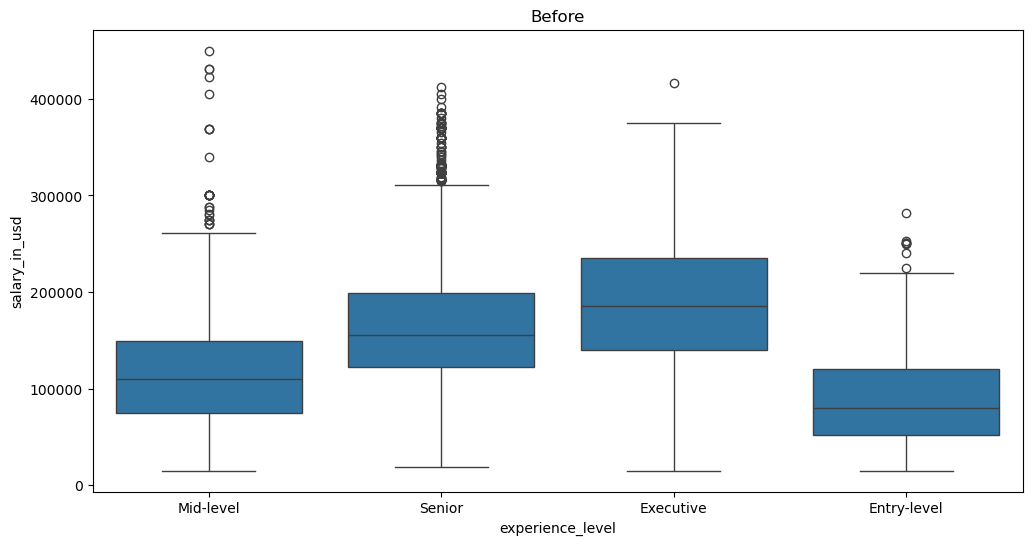

In [13]:
# 이상치 제거 전 boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df)
plt.title('Before')
plt.show()

In [17]:
# 이상치 제거 함수
def remove_outliers_iqr(gr, col):
    Q1 = gr[col].quantile(0.25)
    Q3 = gr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return gr[(gr[col] >= lower_bound) & (gr[col] <= upper_bound)]

In [19]:
# experience_level칼럼의 값에 따라 이상치 제거?
# 1.experience_level별로 그룹화하고 2.이상치 제거
clean_df= df.groupby('experience_level').apply(remove_outliers_iqr, col='salary_in_usd').reset_index(drop=True)

/var/folders/2c/j3wmswps2r5gclvj1skrczqh0000gn/T/ipykernel_33845/1134005208.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  clean_df= df.groupby('experience_level').apply(remove_outliers_iqr, col='salary_in_usd').reset_index(drop=True)


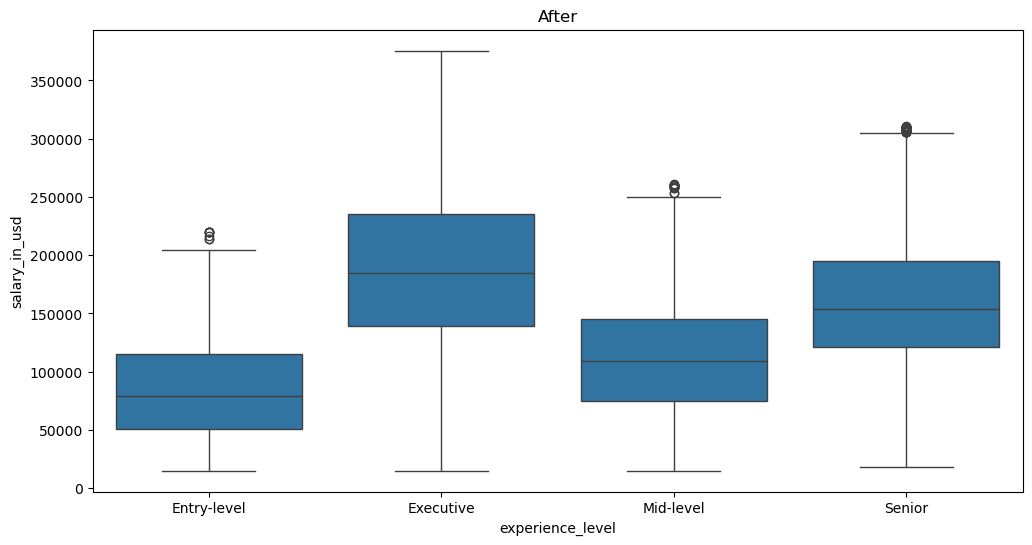

In [21]:
# 이상치 제거 후 boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=clean_df)
plt.title('After')
plt.show()

# 3. work_year : 2023년도인 사람만 살리고, work_year칼럼은 제거

In [23]:
df=clean_df[clean_df['work_year']==2023]
df.drop(columns='work_year',inplace=True)
df.head(10)

/var/folders/2c/j3wmswps2r5gclvj1skrczqh0000gn/T/ipykernel_33845/2505572527.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns='work_year',inplace=True)


,job_title,job_category,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,Data Analyst,Data Analysis,95000,United States,Entry-level,Full-time,In-person,United States,M
1,Data Analyst,Data Analysis,75000,United States,Entry-level,Full-time,In-person,United States,M
2,Research Analyst,Data Science and Research,72000,United States,Entry-level,Full-time,Remote,United States,M
3,Research Analyst,Data Science and Research,64000,United States,Entry-level,Full-time,Remote,United States,M
4,Data Analyst,Data Analysis,100000,United States,Entry-level,Full-time,In-person,United States,M
5,Data Analyst,Data Analysis,75000,United States,Entry-level,Full-time,In-person,United States,M
6,Data Quality Analyst,Data Quality and Operations,49216,United Kingdom,Entry-level,Full-time,Remote,United Kingdom,M
7,Data Quality Analyst,Data Quality and Operations,36912,United Kingdom,Entry-level,Full-time,Remote,United Kingdom,M
8,Data Analyst,Data Analysis,105000,United States,Entry-level,Full-time,In-person,United States,M
9,MLOps Engineer,Machine Learning and AI,133000,United States,Entry-level,Full-time,In-person,United States,M


# 4. job

### (1) job_category 살리고 job_title은 제거

In [25]:
df.drop(columns='job_title',inplace=True)
df.head(10)

/var/folders/2c/j3wmswps2r5gclvj1skrczqh0000gn/T/ipykernel_33845/1023741209.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns='job_title',inplace=True)


,job_category,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,Data Analysis,95000,United States,Entry-level,Full-time,In-person,United States,M
1,Data Analysis,75000,United States,Entry-level,Full-time,In-person,United States,M
2,Data Science and Research,72000,United States,Entry-level,Full-time,Remote,United States,M
3,Data Science and Research,64000,United States,Entry-level,Full-time,Remote,United States,M
4,Data Analysis,100000,United States,Entry-level,Full-time,In-person,United States,M
5,Data Analysis,75000,United States,Entry-level,Full-time,In-person,United States,M
6,Data Quality and Operations,49216,United Kingdom,Entry-level,Full-time,Remote,United Kingdom,M
7,Data Quality and Operations,36912,United Kingdom,Entry-level,Full-time,Remote,United Kingdom,M
8,Data Analysis,105000,United States,Entry-level,Full-time,In-person,United States,M
9,Machine Learning and AI,133000,United States,Entry-level,Full-time,In-person,United States,M


## (2) job_category 살려는두고, job_group 칼럼 새로 만들어서 사용
## (분석:0, 관리 및 운영:1, 데이터 처리 및 모델 개발:2)

- 분석(0): Data Analysis, BI and Visualization
- 관리 및 운영(1): Leadership and Management, Data Management and Strategy, Data Quality and Operations, Cloud and Database, 
- 데이터 및 모델 개발(2): Data Science and Research, Data Engineering, Machine Learning and AI, Data Architecture and Modeling

In [33]:
# 매핑
# 그룹 정의
category_mapping = {
    'Data Analysis':'0',
    'BI and Visualization':'0',
    'Leadership and Management':'1', 
    'Data Management and Strategy':'1',
    'Data Quality and Operations':'1', 
    'Cloud and Database':'1',
    'Data Science and Research':'2', 
    'Data Engineering':'2',
    'Machine Learning and AI':'2', 
    'Data Architecture and Modeling':'2'
    
}

# 새로운 컬럼 생성
df['job_group'] = df['job_category'].map(category_mapping)

# 결과 확인
df.head(10)

/var/folders/2c/j3wmswps2r5gclvj1skrczqh0000gn/T/ipykernel_33845/2287783748.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['job_group'] = df['job_category'].map(category_mapping)


,job_category,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size,job_group
0,Data Analysis,95000,United States,Entry-level,Full-time,In-person,United States,M,0
1,Data Analysis,75000,United States,Entry-level,Full-time,In-person,United States,M,0
2,Data Science and Research,72000,United States,Entry-level,Full-time,Remote,United States,M,2
3,Data Science and Research,64000,United States,Entry-level,Full-time,Remote,United States,M,2
4,Data Analysis,100000,United States,Entry-level,Full-time,In-person,United States,M,0
5,Data Analysis,75000,United States,Entry-level,Full-time,In-person,United States,M,0
6,Data Quality and Operations,49216,United Kingdom,Entry-level,Full-time,Remote,United Kingdom,M,1
7,Data Quality and Operations,36912,United Kingdom,Entry-level,Full-time,Remote,United Kingdom,M,1
8,Data Analysis,105000,United States,Entry-level,Full-time,In-person,United States,M,0
9,Machine Learning and AI,133000,United States,Entry-level,Full-time,In-person,United States,M,2


# 5.employee_residence만 제거

In [35]:
df.drop(columns='employee_residence',inplace=True)
df.head(10)

/var/folders/2c/j3wmswps2r5gclvj1skrczqh0000gn/T/ipykernel_33845/2237773968.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns='employee_residence',inplace=True)


,job_category,salary_in_usd,experience_level,employment_type,work_setting,company_location,company_size,job_group
0,Data Analysis,95000,Entry-level,Full-time,In-person,United States,M,0
1,Data Analysis,75000,Entry-level,Full-time,In-person,United States,M,0
2,Data Science and Research,72000,Entry-level,Full-time,Remote,United States,M,2
3,Data Science and Research,64000,Entry-level,Full-time,Remote,United States,M,2
4,Data Analysis,100000,Entry-level,Full-time,In-person,United States,M,0
5,Data Analysis,75000,Entry-level,Full-time,In-person,United States,M,0
6,Data Quality and Operations,49216,Entry-level,Full-time,Remote,United Kingdom,M,1
7,Data Quality and Operations,36912,Entry-level,Full-time,Remote,United Kingdom,M,1
8,Data Analysis,105000,Entry-level,Full-time,In-person,United States,M,0
9,Machine Learning and AI,133000,Entry-level,Full-time,In-person,United States,M,2


# 6. csv 파일로 저장

In [37]:
# 특정 경로에 저장
df.to_csv('/Users/bluecloud/Documents/대학/유런/데이터셋/cleand_jobs.csv', index=False)